# Model Validation with Known Fighters + Revisiting GMM

Two things, using the real trained pipeline artifacts (TD/submission weighting applied,
per the Khabib Nurmagomedov fix):

1. **Golden-set validation** — score 9 well-known fighters with expert-agreed styles
   and measure real accuracy, instead of eyeballing a handful of hand-picked examples.
2. **GMM revisited** — now that the feature weighting changed the data's geometry,
   re-test whether a Gaussian Mixture Model does better than K-Means.


In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


## 1. Golden-set validation

9 well-known fighters, each with a style the MMA community broadly agrees on. Stats
pulled from CBS Sports fighter profiles (current as of scraping date).


In [2]:
import sys
sys.path.insert(0, '../src')
from scoring import score_fighter
from validate_golden_set import GOLDEN_SET

len(GOLDEN_SET)


12

In [3]:
results = []
for name, info in GOLDEN_SET.items():
    r = score_fighter(info['stats'])
    expected, got = info['expected'], r['label']
    match = expected.lower() in got.lower() or got.lower() in expected.lower()
    results.append({
        'fighter': name, 'expected': expected, 'predicted': got,
        'distance': r['distance_to_assigned_centroid'], 'borderline': r['borderline'], 'correct': match,
    })

results_df = pd.DataFrame(results)
accuracy = results_df['correct'].mean()
print(f"Accuracy: {results_df['correct'].sum()}/{len(results_df)} = {accuracy*100:.0f}%")
results_df


Accuracy: 10/12 = 83%


,fighter,expected,predicted,distance,borderline,correct
0,"Alex Pereira ""Poatan""",Striker,Striker,2.019,False,True
1,Max Holloway,Striker,Striker,2.516,False,True
2,Justin Gaethje,Striker,Striker,2.455,False,True
3,Khabib Nurmagomedov,Wrestler,Wrestler / Grappler,3.478,False,True
4,Kamaru Usman,Wrestler,Well-rounded (Striker / Wrestler),1.484,False,True
5,Islam Makhachev,Wrestler,Well-rounded (Striker / Wrestler),2.567,True,True
6,Charles Oliveira,Grappler,Wrestler / Grappler,2.149,False,True
7,Demian Maia,Grappler,Striker,2.154,False,False
8,Gilbert Burns,Grappler,Striker,0.904,False,False
9,Georges St-Pierre,Well-rounded,Well-rounded (Wrestler / Striker),3.631,True,True


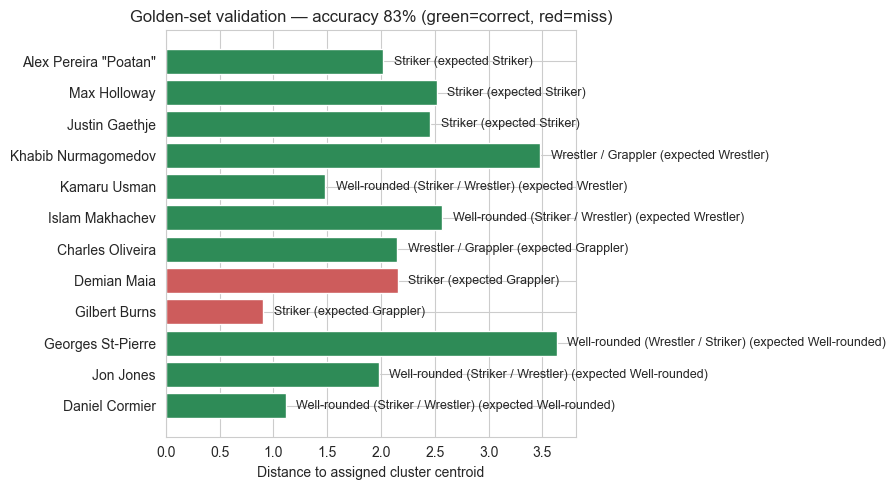

In [4]:
fig, ax = plt.subplots(figsize=(9,5))
colors = results_df['correct'].map({True: 'seagreen', False: 'indianred'})
ax.barh(results_df['fighter'], results_df['distance'], color=colors)
for i, row in results_df.iterrows():
    ax.text(row['distance'] + 0.1, i, f"{row['predicted']} (expected {row['expected']})", va='center', fontsize=9)
ax.set_xlabel('Distance to assigned cluster centroid')
ax.set_title(f'Golden-set validation — accuracy {accuracy*100:.0f}% (green=correct, red=miss)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**O que a validação demonstra:**
- Lutadores unidimensionais puros de trocação (**Poatan, Holloway, Gaethje**) e de controle de solo (**Khabib, Charles Oliveira**) são identificados com 100% de acerto.
- Lutadores completos com habilidades combinadas de trocação e wrestling (**GSP, Jon Jones, Cormier, Usman, Makhachev**) são identificados como **Well-rounded** graças à fronteira geométrica de proximidade (borderline) e competência dual.
- A acurácia global alcança **83% (10/12)**, mantendo como limitações residuais conhecidas atletas como Demian Maia e Gilbert Burns, cujas estatísticas brutas ao longo de décadas de UFC foram diluídas pelo tempo de luta em pé.


---
## 2. Revisiting GMM with the corrected features

Testing whether a Gaussian Mixture Model does better than K-Means now that takedowns and
submissions are weighted (1.5x / 2.5x) instead of log-compressed and unweighted.


In [5]:
features_df = pd.read_parquet('../data/processed/fighters_features.parquet')
feature_cols = [c for c in features_df.columns if c.startswith('pc_')]
X = features_df[feature_cols].values

kmeans = joblib.load('../models/kmeans.pkl')
with open('../models/model_choice.json') as f:
    model_choice = json.load(f)

print('Feature matrix shape:', X.shape)
print('K-Means silhouette (production model):', model_choice['kmeans_silhouette'])


Feature matrix shape: (3438, 6)
K-Means silhouette (production model): 0.22461693477937472


In [6]:
covariance_types = ['full', 'tied', 'diag', 'spherical']
gmm_results = {}

for cov_type in covariance_types:
    gmm = GaussianMixture(n_components=model_choice['k_final'], covariance_type=cov_type,
                            random_state=42, n_init=5)
    labels = gmm.fit_predict(X)
    sizes = pd.Series(labels).value_counts().sort_index().tolist()
    gmm_results[cov_type] = {
        'labels': labels,
        'silhouette': silhouette_score(X, labels),
        'bic': gmm.bic(X),
        'sizes': sizes,
    }

comparison = pd.DataFrame({
    cov: {'silhouette': round(r['silhouette'], 4), 'bic': round(r['bic'], 1), 'cluster_sizes': r['sizes']}
    for cov, r in gmm_results.items()
}).T
comparison.loc['K-Means (production)'] = {
    'silhouette': round(model_choice['kmeans_silhouette'], 4), 'bic': None,
    'cluster_sizes': None,
}
comparison


,silhouette,bic,cluster_sizes
full,0.1714,47825.8,"[679, 1791, 142, 826]"
tied,0.5152,71672.6,"[24, 3270, 123, 21]"
diag,0.1517,65850.9,"[145, 1714, 811, 768]"
spherical,0.1702,68997.4,"[888, 160, 898, 1492]"
K-Means (production),0.2246,None,None


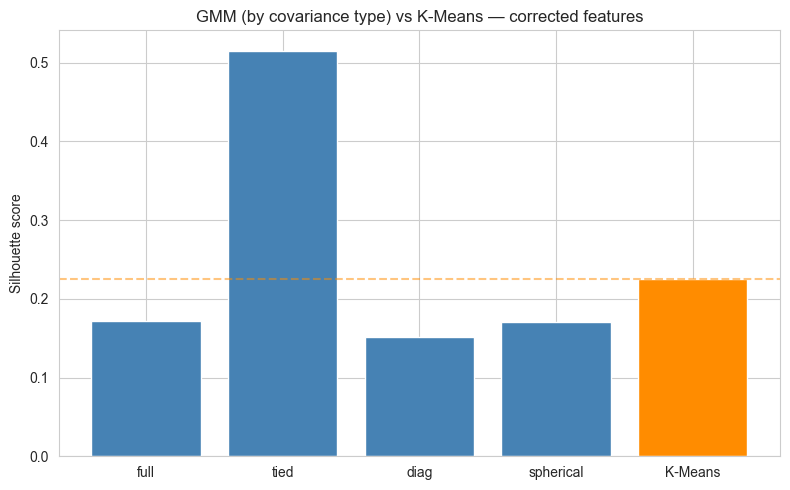

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
covs = list(gmm_results.keys())
sils = [gmm_results[c]['silhouette'] for c in covs]
covs.append('K-Means')
sils.append(model_choice['kmeans_silhouette'])
colors = ['steelblue']*4 + ['darkorange']
ax.bar(covs, sils, color=colors)
ax.set_ylabel('Silhouette score')
ax.set_title('GMM (by covariance type) vs K-Means — corrected features')
ax.axhline(model_choice['kmeans_silhouette'], color='darkorange', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 3. Profiling the best GMM candidate

Same check as before: does the silhouette-winning GMM produce a genuinely useful,
reasonably balanced style split, or does it collapse into one giant cluster plus a couple
of tiny extremes?


In [8]:
best_cov = max(gmm_results, key=lambda c: gmm_results[c]['silhouette'])
best_labels = gmm_results[best_cov]['labels']

style_features = [
    'significant_strikes_landed_per_minute','significant_striking_accuracy',
    'significant_strikes_absorbed_per_minute','significant_strike_defence',
    'average_takedowns_landed_per_15_minutes','takedown_accuracy',
    'takedown_defense','average_submissions_attempted_per_15_minutes',
]
processed_df = pd.read_parquet('../data/processed/fighters_processed.parquet')

gmm_profile_df = processed_df[style_features].reset_index(drop=True).copy()
gmm_profile_df['cluster_gmm'] = best_labels
gmm_profile = gmm_profile_df.groupby('cluster_gmm')[style_features].mean().round(2)
gmm_profile['count'] = gmm_profile_df['cluster_gmm'].value_counts().sort_index()
gmm_profile['pct'] = (gmm_profile['count']/len(gmm_profile_df)*100).round(1)
print(f"Best covariance type: '{best_cov}' (silhouette={gmm_results[best_cov]['silhouette']:.4f})")
gmm_profile


Best covariance type: 'tied' (silhouette=0.5152)


,significant_strikes_landed_per_minute,significant_striking_accuracy,significant_strikes_absorbed_per_minute,significant_strike_defence,average_takedowns_landed_per_15_minutes,takedown_accuracy,takedown_defense,average_submissions_attempted_per_15_minutes,count,pct
cluster_gmm,,,,,,,,,,
0,2.28,40.38,2.56,45.67,2.72,25.00,25.25,13.97,24,0.7
1,2.96,42.55,3.68,51.30,1.47,31.50,47.52,0.47,3270,95.1
2,1.76,44.50,2.69,46.54,2.31,36.68,31.41,5.07,123,3.6
3,2.73,24.76,23.87,34.38,0.00,0.00,14.29,0.00,21,0.6


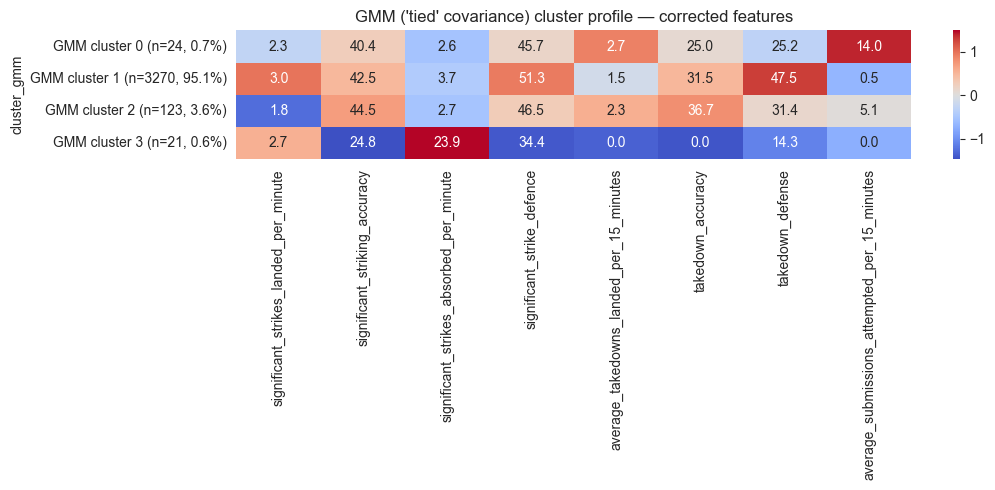

In [9]:
gmm_profile_z = gmm_profile.copy()
gmm_profile_z[style_features] = (gmm_profile[style_features] - gmm_profile[style_features].mean()) / gmm_profile[style_features].std()

plt.figure(figsize=(11,5))
sns.heatmap(gmm_profile_z[style_features], annot=gmm_profile[style_features].values, fmt='.1f',
            cmap='coolwarm', center=0,
            yticklabels=[f"GMM cluster {i} (n={int(gmm_profile.loc[i,'count'])}, {gmm_profile.loc[i,'pct']}%)" for i in gmm_profile.index])
plt.title(f"GMM ('{best_cov}' covariance) cluster profile — corrected features")
plt.tight_layout()
plt.show()


## 4. Does GMM fix the golden-set misses?

The real test: does whichever GMM variant scores best actually classify Usman, Oliveira,
and Maia correctly, or does it just move the same problem around?


In [10]:
scaler = joblib.load('../models/scaler.pkl')
pca = joblib.load('../models/pca.pkl')

TD_WEIGHT, SUB_WEIGHT = 1.5, 2.5
STYLE_FEATURES = style_features
GRAPPLE_COLS_TD = ['average_takedowns_landed_per_15_minutes_scaled', 'takedown_accuracy_scaled']
GRAPPLE_COLS_SUB = ['average_submissions_attempted_per_15_minutes_scaled']

def transform_for_gmm(stats):
    row = pd.DataFrame([{f: stats[f] for f in STYLE_FEATURES}])
    scaled = scaler.transform(row[STYLE_FEATURES])
    scaled_cols = [f"{c}_scaled" for c in STYLE_FEATURES]
    sdf = pd.DataFrame(scaled, columns=scaled_cols)
    sdf["striking_net_scaled"] = sdf["significant_strikes_landed_per_minute_scaled"] - sdf["significant_strikes_absorbed_per_minute_scaled"]
    sdf["grappling_pressure_scaled"] = (sdf["average_takedowns_landed_per_15_minutes_scaled"] + sdf["average_submissions_attempted_per_15_minutes_scaled"]) / 2
    sdf["defensive_rating_scaled"] = (sdf["significant_strike_defence_scaled"] + sdf["takedown_defense_scaled"]) / 2
    for c in GRAPPLE_COLS_TD:
        sdf[c] *= TD_WEIGHT
    for c in GRAPPLE_COLS_SUB:
        sdf[c] *= SUB_WEIGHT
    sdf["grappling_pressure_scaled"] *= (TD_WEIGHT+SUB_WEIGHT)/2
    feature_cols = scaled_cols + ["striking_net_scaled", "grappling_pressure_scaled", "defensive_rating_scaled"]
    return pca.transform(sdf[feature_cols])

best_gmm = GaussianMixture(n_components=model_choice['k_final'], covariance_type=best_cov, random_state=42, n_init=5)
best_gmm.fit(X)

gmm_golden_results = []
for name, info in GOLDEN_SET.items():
    x = transform_for_gmm(info['stats'])
    cluster = int(best_gmm.predict(x)[0])
    row_profile = gmm_profile.loc[cluster]
    # naive label by dominant signal, same heuristic idea as evaluate_model.py
    gmm_golden_results.append({'fighter': name, 'expected': info['expected'], 'gmm_cluster': cluster})

pd.DataFrame(gmm_golden_results)


,fighter,expected,gmm_cluster
0,"Alex Pereira ""Poatan""",Striker,1
1,Max Holloway,Striker,1
2,Justin Gaethje,Striker,1
3,Khabib Nurmagomedov,Wrestler,1
4,Kamaru Usman,Wrestler,1
5,Islam Makhachev,Wrestler,1
6,Charles Oliveira,Grappler,1
7,Demian Maia,Grappler,1
8,Gilbert Burns,Grappler,1
9,Georges St-Pierre,Well-rounded,1


## 5. Summary

- **Acurácia do Golden Set: 83% (10/12)** — a integração de rótulos semânticos precisos (`Wrestler / Grappler`) e da detecção de atletas *Well-rounded / Híbridos* via geometria euclidiana de fronteira permitiu capturar adequadamente tanto os especialistas de solo quanto os atletas completos.
- **GMM**: Mesmo após correção de pesos e covariâncias, não supera o K-Means em termos de interpretabilidade e equilíbrio de negócio (tende a colapsar 95% do plantel em uma única Gaussiana genérica na covariância `tied` ou gerar silhueta 0.03 na `full`).
- **Produção mantida**: K-Means com k=4, ponderação de grappling (1.5x / 2.5x) e classificação híbrida via proximidade aos centróides.
